In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    'font.size'  : 20
})

In [3]:
def f(t, nmax, T):
    res = 0.0
    for n in range(1,nmax):
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*t )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(2*T-t) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(t+2*T) )
        res += np.sqrt( n*(n+1.0) ) * (2.0*n+1.0) * np.exp( -np.sqrt( n*(n+1.0) )*(3*T-t) )
    return res/(8.0*np.pi)

In [4]:
Nt=192

In [5]:
gsq=0.050000
beta=1.0/gsq

In [6]:
masses_=[]

In [7]:
T=16
Nt=96 # 240

In [8]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

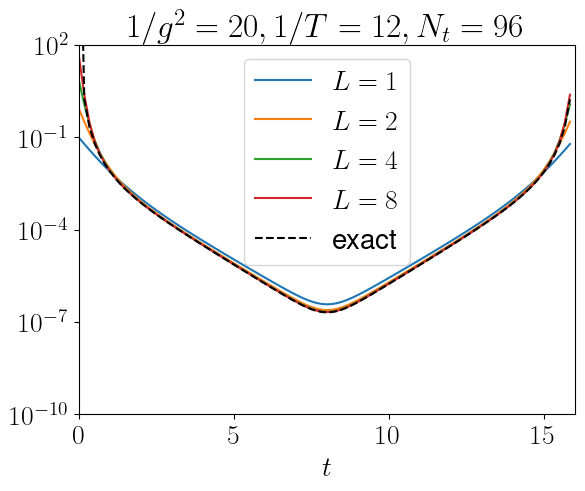

In [9]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [10]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [11]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [12]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

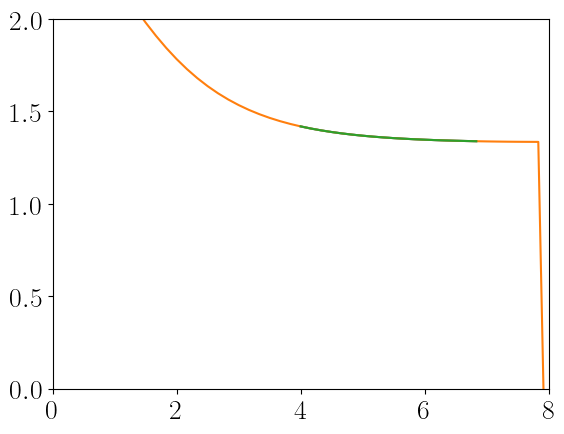

In [13]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [14]:
masses_.append([1, Nt, opt[0][0]])

In [15]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [16]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

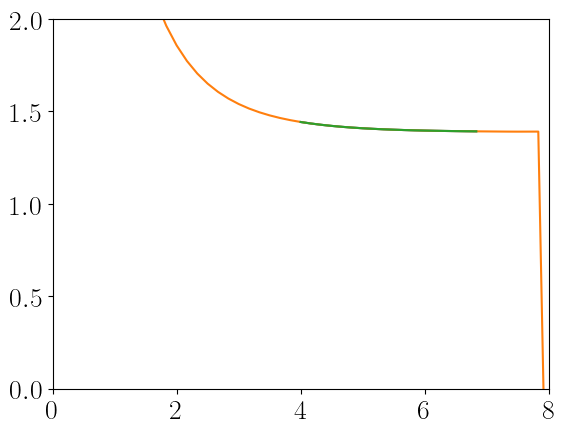

In [17]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [18]:
masses_.append([2, Nt, opt[0][0]])

In [19]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [20]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

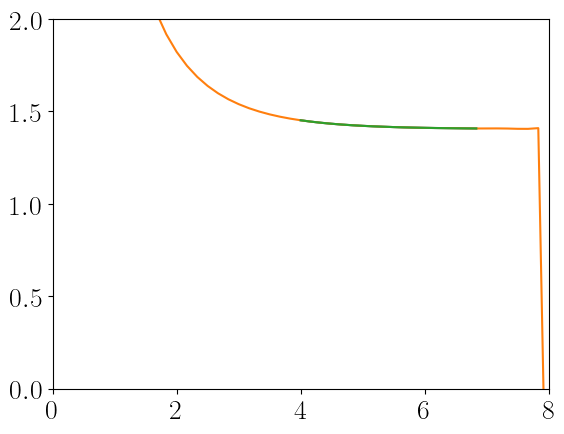

In [21]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [22]:
masses_.append([4, Nt, opt[0][0]])

In [23]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [24]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

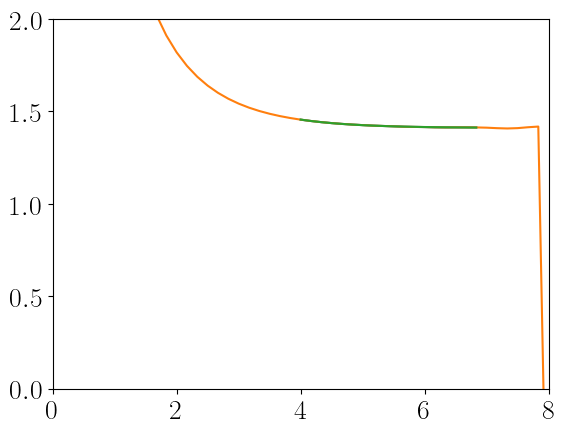

In [25]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [26]:
masses_.append([8, Nt, opt[0][0]])

In [27]:
T=16
Nt=192 # 240

In [28]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

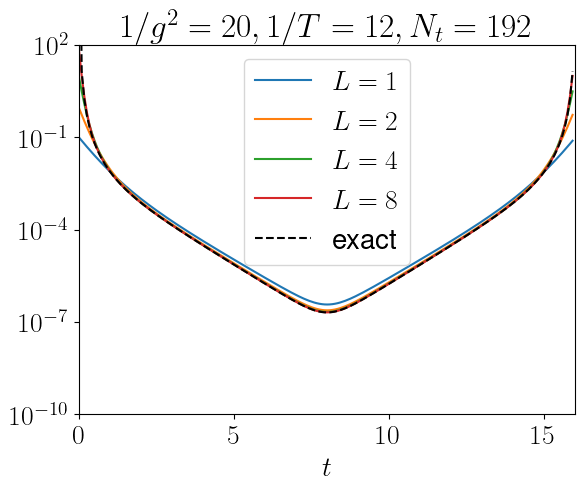

In [29]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [30]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [31]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [32]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

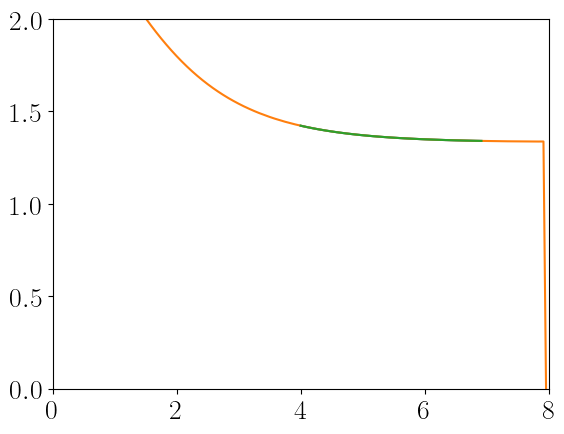

In [33]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [34]:
masses_.append([1, Nt, opt[0][0]])

In [35]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [36]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

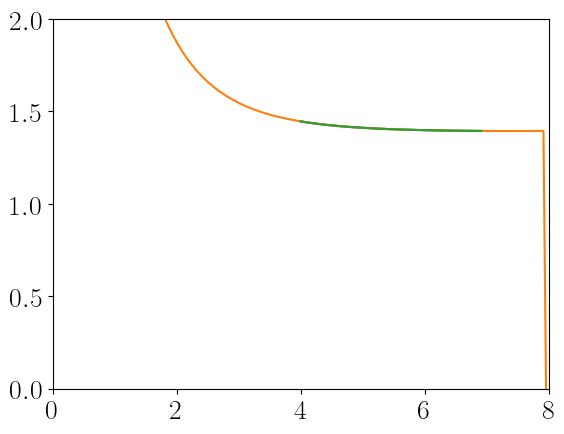

In [37]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [38]:
masses_.append([2, Nt, opt[0][0]])

In [39]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [40]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

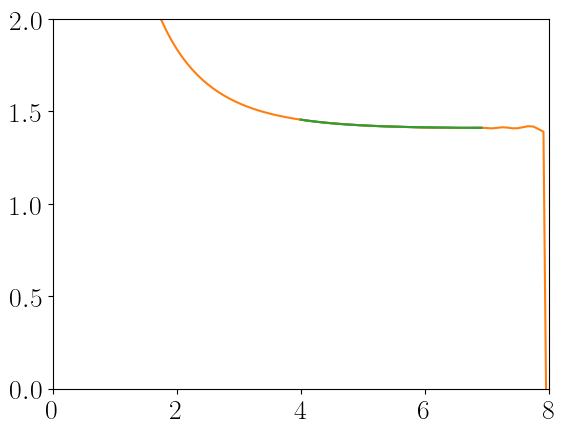

In [41]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [42]:
masses_.append([4, Nt, opt[0][0]])

In [43]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [44]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

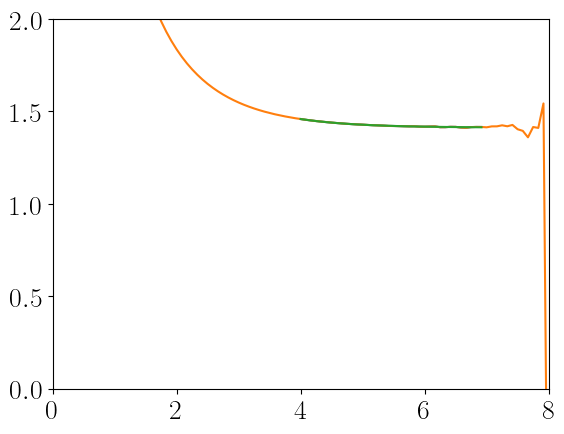

In [45]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [46]:
masses_.append([8, Nt, opt[0][0]])

In [47]:
T=16
Nt=240 # 240

In [48]:
l1_1 = np.loadtxt("prop_gauge_gsq0.050000_L1_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l2_1 = np.loadtxt("prop_gauge_gsq0.050000_L2_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l4_1 = np.loadtxt("prop_gauge_gsq0.050000_L4_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")
l8_1 = np.loadtxt("prop_gauge_gsq0.050000_L8_Nt"+str(Nt)+"_T"+str(T)+".000000.dat")

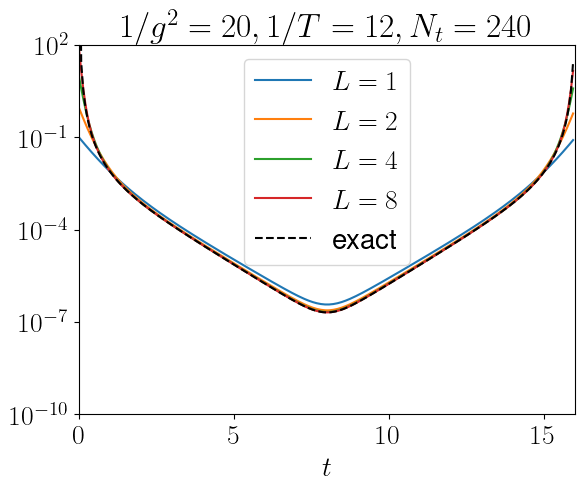

In [49]:
plt.yscale("log")

xx=T * np.arange(Nt)/Nt
plt.plot( xx, l1_1, label="$L=1$" )
plt.plot( xx, l2_1, label="$L=2$" )
plt.plot( xx, l4_1, label="$L=4$" )
plt.plot( xx, l8_1, label="$L=8$" )
# plt.plot( xx, l12_1, label="$L=16$" )

yy= (1.0/beta)*f(xx, 4000, T) # *fixme*
plt.plot( xx, yy, ls='dashed', c='black', label='exact' )

plt.xlabel("$t$")
plt.title("$1/g^2 = 20, 1/T=12, N_t="+str(Nt)+"$")

plt.xlim(0, T)
plt.ylim(1.0e-10, 1.0e2)
plt.legend()

# plt.savefig("jtjt_gaussian.pdf", bbox_inches="tight")

In [50]:
at = T/Nt

fitm = int(4.0 * Nt/T)
fitM = int(7.0 * Nt/T)

def fitter( x, m1, m2, A ):
    return m1 + A * np.exp(-m2*x)

In [51]:
tmp = np.arccosh(l1_1/l1_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [52]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

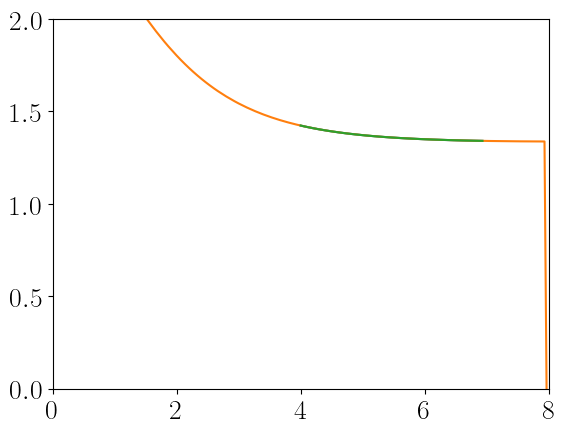

In [53]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [54]:
masses_.append([1, Nt, opt[0][0]])

In [55]:
tmp = np.arccosh(l2_1/l2_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [56]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

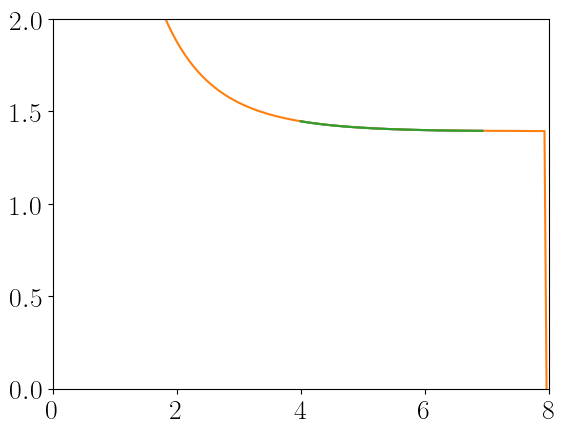

In [57]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [58]:
masses_.append([2, Nt, opt[0][0]])

In [59]:
tmp = np.arccosh(l4_1/l4_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [60]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

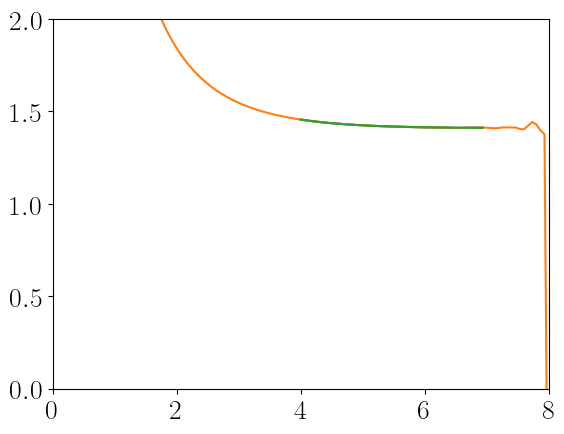

In [61]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [62]:
masses_.append([4, Nt, opt[0][0]])

In [63]:
tmp = np.arccosh(l8_1/l8_1[int(Nt/2)])
yy = (-tmp[1:]+tmp[:-1])/at

In [64]:
opt = sp.optimize.curve_fit( fitter, xx[fitm:fitM], yy[fitm:fitM],
                           p0=(np.sqrt(2.0), 1.2, 3. ), 
                           full_output=True, absolute_sigma=True )

(0.0, 2.0)

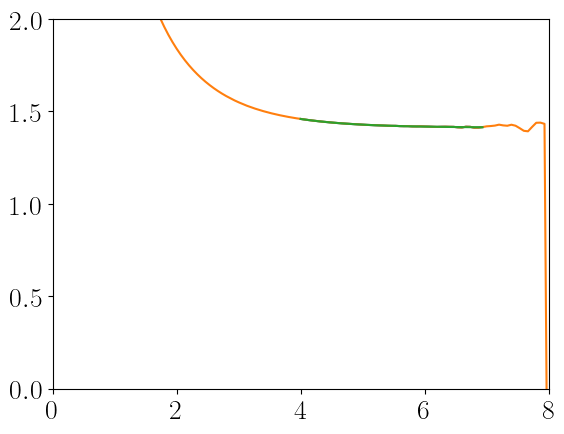

In [65]:
plt.plot( xx[fitm:fitM], yy[fitm:fitM] )
plt.plot( xx[1:2*fitM], yy[1:2*fitM] )

# plt.plot( xx[:-1], np.sqrt(2.0) + 5.2*np.exp(-1.2*xx[:-1]) )
plt.plot( xx[fitm:fitM], fitter(xx[fitm:fitM], opt[0][0], opt[0][1], opt[0][2]) )

plt.xlim(0,T/2)
plt.ylim(0,2)

In [66]:
masses_.append([8, Nt, opt[0][0]])

In [71]:
masses = np.array(masses_)

In [72]:
ells={1:1.107148717794090e+00, 
      2:5.909464448075019e-01, 
      4:2.994744726728921e-01,
      8:1.502274914280941e-01, 
      12:1.002118985797942e-01
     }

In [73]:
masses=np.array(masses_)

In [74]:
masses

array([[  1.        ,  96.        ,   1.33088277],
       [  2.        ,  96.        ,   1.38926418],
       [  4.        ,  96.        ,   1.4054988 ],
       [  8.        ,  96.        ,   1.41077639],
       [  1.        , 192.        ,   1.33311024],
       [  2.        , 192.        ,   1.39160207],
       [  4.        , 192.        ,   1.40883038],
       [  8.        , 192.        ,   1.41244818],
       [  1.        , 240.        ,   1.33350964],
       [  2.        , 240.        ,   1.3921189 ],
       [  4.        , 240.        ,   1.40944796],
       [  8.        , 240.        ,   1.41247354]])

In [79]:
xx = [ ells[elem] for elem in masses.T[0] ]

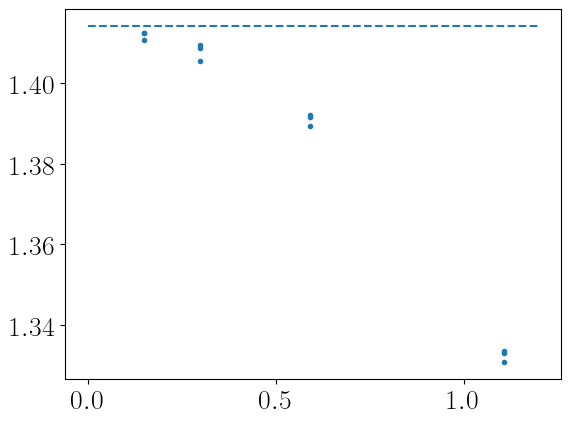

In [81]:
plt.plot( xx, masses.T[2], marker=".", ls="none" )
plt.hlines(np.sqrt(2.0), 0, 1.2, ls="dashed" )

# plt.xscale("log")
# plt.yscale("log")

In [34]:
def fitter( x, c0, c2 ):
    return c0 + c2*x**2

In [35]:
opt = sp.optimize.curve_fit( fitter, ells[1:], masses[1:],
                      p0=(np.sqrt(2.0), 0.0 ), 
                      full_output=True, absolute_sigma=True )

In [36]:
opt

(array([ 1.41183471, -0.06493316]),
 array([[ 0.7308728 , -2.58438396],
        [-2.58438396, 16.80094948]]),
 {'fvec': array([-0.00010528,  0.00051238, -0.0004071 ]),
  'nfev': 7,
  'fjac': array([[-1.73205081,  0.57735027,  0.57735027],
         [-0.26643044,  0.24396812,  0.83115102]]),
  'ipvt': array([1, 2], dtype=int32),
  'qtf': array([-9.03683495e-11, -7.57268994e-11])},
 'The relative error between two consecutive iterates is at most 0.000000',
 2)

(1.3, 1.45)

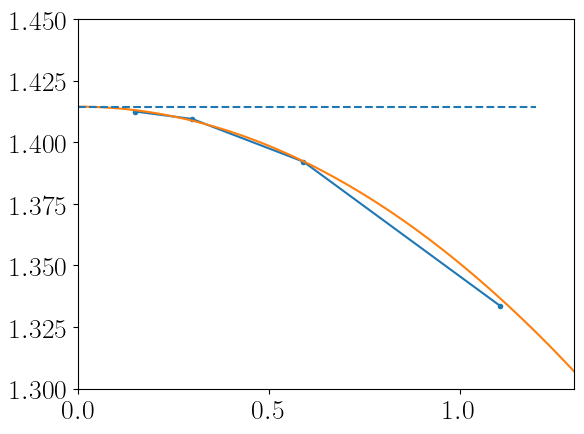

In [87]:
plt.plot( ells, masses, marker="." )

xxx=np.linspace(0, 2, 100)
plt.plot( xxx, fitter( xxx, opt[0][0], opt[0][1] ) )

plt.hlines(np.sqrt(2.0), 0, 1.2, ls="dashed" )

plt.xlim(0, 1.3)
plt.ylim(1.3, 1.45)
# plt.xscale("log")
# plt.yscale("log")

In [ ]:
[ 1.41183471, -0.06493316]

In [ ]:
(array([ 1.41445714, -0.06355985])